In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import re
import json
import uuid
import pandas as pd
import numpy as np

from tqdm import tqdm

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD FEATURE ENGINEERED DATASET
# ============================================================

DATASET_PATH = "../../parquet_exports_v2/feature_engineered_v2.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 108,421
Columns : 30


,document_id,rag_id,problem_text_clean,solution_text_clean,metadata_json,source_system_encoded,category_encoded,language_encoded,product_encoded,priority_encoded,problem_word_count,problem_char_count,problem_avg_word_length,problem_unique_word_ratio,problem_uppercase_ratio,problem_digit_ratio,problem_special_char_ratio,problem_repetition_ratio,problem_complexity_score,solution_word_count,solution_char_count,solution_avg_word_length,solution_unique_word_ratio,solution_uppercase_ratio,solution_digit_ratio,solution_special_char_ratio,solution_repetition_ratio,solution_complexity_score,retrieval_quality_score,escalation_risk_score
0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,i am unable to access my account after enterin...,security settings updated and customer notifie...,"{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,8,4,8,0,24,145,5.083333,0.5,0.0,0.0,0.013793,0.5,2.281333,9,74,7.333333,1.0,0.0,0.0,0.013514,0.0,3.351333,2.3125,2.594900
1,doc_1,504f35fd3b03f048a1984f89fffb08e1,i would like to request a refund for the recen...,explained billing breakdown and clarified appl...,"{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",0,6,4,5,3,22,111,4.090909,0.5,0.0,0.0,0.018018,0.5,1.880364,7,61,7.857143,1.0,0.0,0.0,0.016393,0.0,3.556857,1.5750,2.625583
2,doc_2,db7bc1e2f75fa986ee832c31e320a2de,there seems to be a discrepancy in my billing ...,provided step-by-step troubleshooting instruct...,"{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",0,10,3,4,1,26,143,4.538462,0.5,0.0,0.0,0.013986,0.5,2.067385,7,70,9.142857,1.0,0.0,0.0,0.042857,0.0,4.071143,3.1250,3.720779
3,doc_3,01d7f2addbcc200f88368695230ea06e,the system is not syncing data across devices ...,bug logged internally and workaround shared wi...,"{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",0,7,0,1,2,18,111,5.222222,0.5,0.0,0.0,0.018018,0.5,2.324889,9,62,6.000000,1.0,0.0,0.0,0.016129,0.0,2.818000,2.6125,3.361433
4,doc_4,aa219338e9e467aadb53d3d1a9026de7,i am unable to access my account after enterin...,provided step-by-step troubleshooting instruct...,"{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",0,12,5,4,2,24,145,5.083333,0.5,0.0,0.0,0.013793,0.5,2.281333,7,70,9.142857,1.0,0.0,0.0,0.042857,0.0,4.071143,2.9500,3.862871


In [3]:
# ============================================================
# CELL 3 — BUILD RETRIEVAL TEXT (Problem + Resolution + Context)
# ============================================================

PROBLEM_COL = "problem_text_clean"
SOLUTION_COL = "solution_text_clean"


def build_retrieval_document(row: pd.Series) -> str:
    """
    Build a structured retrieval document from a solved incident.

    Format:
        [PROBLEM]
        <problem description>

        [RESOLUTION]
        <solution description>

        [CONTEXT]
        Category  : <category>
        Priority  : <priority>
        Product   : <product>
        Language  : <language>
        Escalation: <escalation_risk_level>
        SLA Status: <sla status>
    """

    problem = str(row.get(PROBLEM_COL, "")).strip()
    solution = str(row.get(SOLUTION_COL, "")).strip()

    parts = []

    parts.append("[PROBLEM]")
    parts.append(problem if problem else "No problem description available.")

    parts.append("[RESOLUTION]")
    parts.append(solution if solution else "No resolution description available.")

    parts.append("[CONTEXT]")

    try:
        meta = json.loads(row.get("metadata_json", "{}"))
    except Exception:
        meta = {}

    parts.append(f"Category  : {meta.get('category', 'unknown')}")
    parts.append(f"Priority  : {meta.get('priority', 'unknown')}")
    parts.append(f"Product   : {meta.get('product', 'unknown')}")
    parts.append(f"Language  : {meta.get('language', 'unknown')}")
    parts.append(f"Escalation: {meta.get('escalation_risk_level', 'unknown')}")
    parts.append(f"SLA Status: {'breached' if meta.get('is_sla_breached') else 'met'}")

    return "\n".join(parts)


RETRIEVAL_TEXT_COLUMN = "retrieval_text_clean"

df[RETRIEVAL_TEXT_COLUMN] = df.apply(build_retrieval_document, axis=1)

print("Retrieval documents built successfully.")

print(df[RETRIEVAL_TEXT_COLUMN].iloc[0][:500])

Retrieval documents built successfully.
[PROBLEM]
i am unable to access my account after entering the correct credentials. i am unable to access my account after entering the correct credentials.
[RESOLUTION]
security settings updated and customer notified of precautionary measures.
[CONTEXT]
Category  : performance issue
Priority  : critical
Product   : Subscription Service
Language  : french
Escalation: low
SLA Status: breached


In [4]:
# ============================================================
# CELL 4 — VALIDATE RETRIEVAL TEXT
# ============================================================

empty_rows = (
    df[RETRIEVAL_TEXT_COLUMN]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

duplicate_texts = (
    df[RETRIEVAL_TEXT_COLUMN]
    .duplicated()
    .sum()
)

print("=" * 60)
print("RETRIEVAL TEXT VALIDATION")
print("=" * 60)

print(f"Empty texts       : {empty_rows:,}")
print(f"Duplicate texts   : {duplicate_texts:,}")

RETRIEVAL TEXT VALIDATION
Empty texts       : 0
Duplicate texts   : 5,434


In [5]:
# ============================================================
# CELL 5 — REMOVE INVALID ROWS
# ============================================================

before_rows = len(df)

# Remove empty texts only
df = df[
    df[RETRIEVAL_TEXT_COLUMN]
    .fillna("")
    .str.strip()
    != ""
].copy()

# Remove duplicate DOCUMENT IDs only
if "document_id" in df.columns:

    df = (
        df
        .drop_duplicates(subset=["document_id"])
        .reset_index(drop=True)
    )

removed_rows = before_rows - len(df)

print("=" * 60)
print("INVALID ROW FILTER")
print("=" * 60)

print(f"Removed rows : {removed_rows:,}")
print(f"Remaining    : {len(df):,}")

INVALID ROW FILTER
Removed rows : 0
Remaining    : 108,421


In [6]:
# ============================================================
# CELL 6 — SIMPLE TOKEN ESTIMATION
# ============================================================

def estimate_tokens(text: str) -> int:
    """
    Rough token estimation.
    Approximation:
    1 token ≈ 0.75 words
    """

    words = str(text).split()

    return int(len(words) / 0.75)


df["estimated_tokens"] = (
    df[RETRIEVAL_TEXT_COLUMN]
    .apply(estimate_tokens)
)

print("estimated_tokens created.")

df["estimated_tokens"].describe()

estimated_tokens created.


count    108421.000000
mean        100.780661
std          58.801728
min          41.000000
25%          68.000000
50%          73.000000
75%          85.000000
max         430.000000
Name: estimated_tokens, dtype: float64

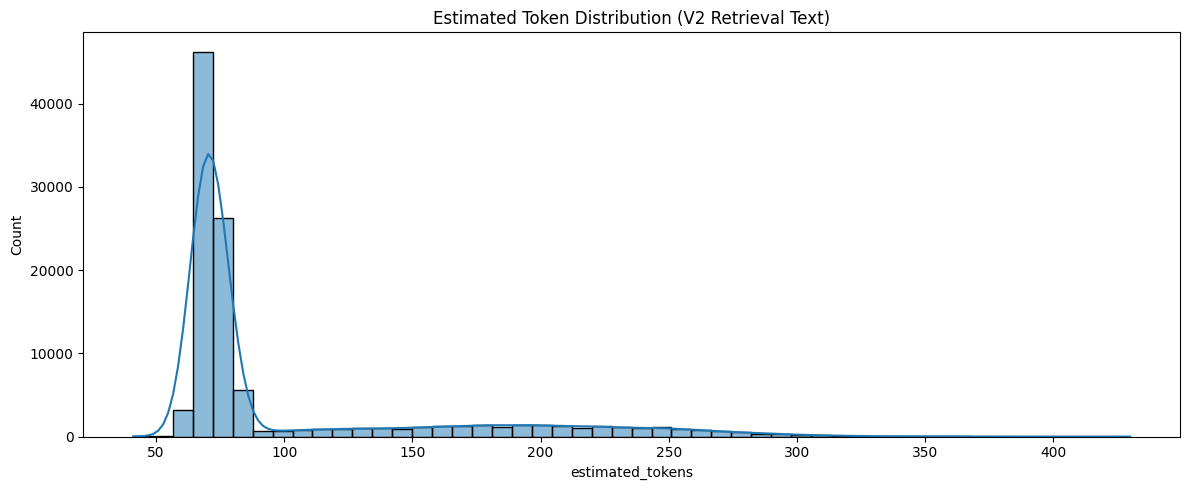

In [7]:
# ============================================================
# CELL 7 — TOKEN DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.histplot(
    df["estimated_tokens"],
    bins=50,
    kde=True
)

plt.title("Estimated Token Distribution (V2 Retrieval Text)")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8 — CHUNKING CONFIG
# ============================================================

CHUNK_SIZE = 256
CHUNK_OVERLAP = 50

print("=" * 60)
print("CHUNKING CONFIG")
print("=" * 60)

print(f"Chunk Size     : {CHUNK_SIZE}")
print(f"Chunk Overlap  : {CHUNK_OVERLAP}")

CHUNKING CONFIG
Chunk Size     : 256
Chunk Overlap  : 50


In [9]:
# ============================================================
# CELL 9 — TEXT CHUNKING FUNCTION
# ============================================================

def chunk_text(
    text: str,
    chunk_size: int = 256,
    overlap: int = 50
):

    words = str(text).split()

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = words[start:end]

        chunks.append(" ".join(chunk))

        start += chunk_size - overlap

    return chunks


print("chunk_text function created.")

chunk_text function created.


In [10]:
# ============================================================
# CELL 10 — GENERATE DOCUMENT CHUNKS
# ============================================================

tqdm.pandas(desc="Chunking documents")

df["chunks"] = (
    df[RETRIEVAL_TEXT_COLUMN]
    .progress_apply(
        lambda x: chunk_text(
            x,
            chunk_size=CHUNK_SIZE,
            overlap=CHUNK_OVERLAP
        )
    )
)

print("Chunks generated successfully.")

df[
    [
        "document_id",
        "chunks"
    ]
].head()

Chunking documents: 100%|██████████| 108421/108421 [00:01<00:00, 54844.76it/s]

Chunks generated successfully.


,document_id,chunks
0,doc_0,[[PROBLEM] i am unable to access my account af...
1,doc_1,[[PROBLEM] i would like to request a refund fo...
2,doc_2,[[PROBLEM] there seems to be a discrepancy in ...
3,doc_3,[[PROBLEM] the system is not syncing data acro...
4,doc_4,[[PROBLEM] i am unable to access my account af...


In [11]:
# ============================================================
# CELL 11 — FLATTEN CHUNKS
# ============================================================

chunk_rows = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    for chunk_index, chunk in enumerate(row["chunks"]):

        chunk_rows.append({
            "chunk_id": f"{row['document_id']}_chunk_{chunk_index}",

            "document_id": row["document_id"],

            "rag_id": row.get("rag_id"),

            "chunk_index": chunk_index,

            "chunk_text": chunk,

            "chunk_word_count": len(chunk.split()),

            "chunk_token_estimate": estimate_tokens(chunk),

            "metadata_json": row.get("metadata_json"),

            "priority_encoded": row.get("priority_encoded"),

            "retrieval_quality_score": row.get("retrieval_quality_score")
        })

chunk_df = pd.DataFrame(chunk_rows)

print("=" * 60)
print("CHUNK DATAFRAME CREATED")
print("=" * 60)

print(f"Total Chunks : {len(chunk_df):,}")

chunk_df.head()

100%|██████████| 108421/108421 [00:16<00:00, 6492.62it/s]


CHUNK DATAFRAME CREATED
Total Chunks : 110,220


,chunk_id,document_id,rag_id,chunk_index,chunk_text,chunk_word_count,chunk_token_estimate,metadata_json,priority_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,0,[PROBLEM] i am unable to access my account aft...,55,73,"{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,2.3125
1,doc_1_chunk_0,doc_1,504f35fd3b03f048a1984f89fffb08e1,0,[PROBLEM] i would like to request a refund for...,51,68,"{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",3,1.5750
2,doc_2_chunk_0,doc_2,db7bc1e2f75fa986ee832c31e320a2de,0,[PROBLEM] there seems to be a discrepancy in m...,55,73,"{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",1,3.1250
3,doc_3_chunk_0,doc_3,01d7f2addbcc200f88368695230ea06e,0,[PROBLEM] the system is not syncing data acros...,49,65,"{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",2,2.6125
4,doc_4_chunk_0,doc_4,aa219338e9e467aadb53d3d1a9026de7,0,[PROBLEM] i am unable to access my account aft...,53,70,"{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",2,2.9500


In [12]:
# ============================================================
# CELL 12 — CHUNK STATISTICS
# ============================================================

print("=" * 60)
print("CHUNK STATISTICS")
print("=" * 60)

print(f"Average Chunk Word Count  : {chunk_df['chunk_word_count'].mean():.2f}")

print(f"Average Token Estimate    : {chunk_df['chunk_token_estimate'].mean():.2f}")

print(f"Max Token Estimate        : {chunk_df['chunk_token_estimate'].max()}")

print(f"Min Token Estimate        : {chunk_df['chunk_token_estimate'].min()}")

CHUNK STATISTICS
Average Chunk Word Count  : 74.83
Average Token Estimate    : 99.47
Max Token Estimate        : 341
Min Token Estimate        : 1


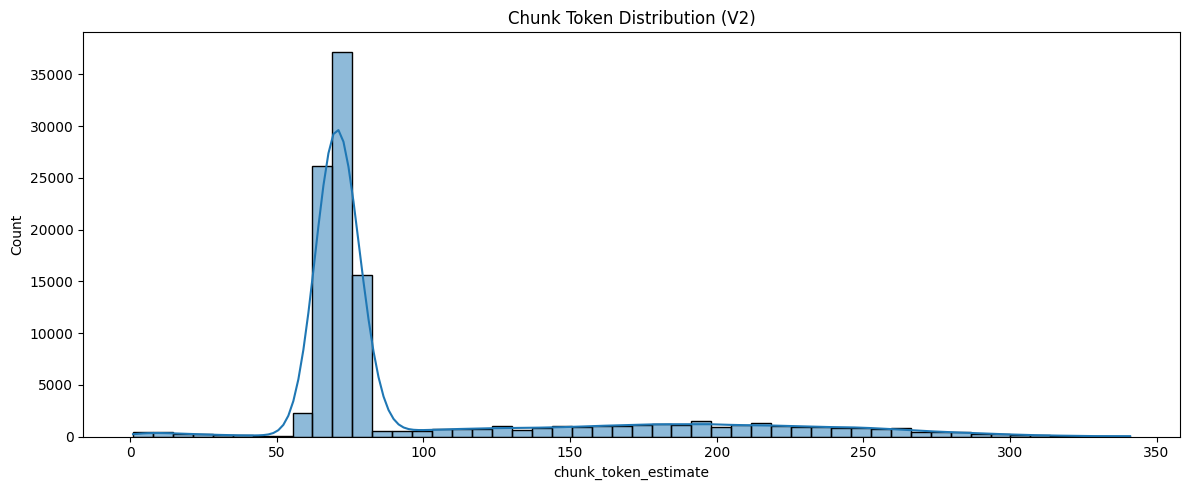

In [13]:
# ============================================================
# CELL 13 — CHUNK TOKEN DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

sns.histplot(
    chunk_df["chunk_token_estimate"],
    bins=50,
    kde=True
)

plt.title("Chunk Token Distribution (V2)")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 14 — BM25 TOKENIZATION PREPARATION
# ============================================================

def bm25_tokenizer(text: str):

    text = str(text)

    text = text.lower()

    tokens = re.findall(r"\b\w+\b", text)

    return tokens


chunk_df["bm25_tokens"] = (
    chunk_df["chunk_text"]
    .apply(bm25_tokenizer)
)

print("BM25 tokenization completed.")

chunk_df[
    [
        "chunk_text",
        "bm25_tokens"
    ]
].head()

BM25 tokenization completed.


,chunk_text,bm25_tokens
0,[PROBLEM] i am unable to access my account aft...,"[problem, i, am, unable, to, access, my, accou..."
1,[PROBLEM] i would like to request a refund for...,"[problem, i, would, like, to, request, a, refu..."
2,[PROBLEM] there seems to be a discrepancy in m...,"[problem, there, seems, to, be, a, discrepancy..."
3,[PROBLEM] the system is not syncing data acros...,"[problem, the, system, is, not, syncing, data,..."
4,[PROBLEM] i am unable to access my account aft...,"[problem, i, am, unable, to, access, my, accou..."


In [15]:
# ============================================================
# CELL 15 — FILTER BAD CHUNKS
# ============================================================

MIN_CHUNK_WORDS = 5

before_chunks = len(chunk_df)

chunk_df = chunk_df[
    chunk_df["chunk_word_count"] >= MIN_CHUNK_WORDS
].copy()

removed_chunks = before_chunks - len(chunk_df)

print("=" * 60)
print("BAD CHUNK FILTER")
print("=" * 60)

print(f"Removed chunks : {removed_chunks:,}")
print(f"Remaining      : {len(chunk_df):,}")

BAD CHUNK FILTER
Removed chunks : 345
Remaining      : 109,875


In [16]:
# ============================================================
# CELL 16 — RETRIEVAL METADATA VALIDATION
# ============================================================

missing_metadata = (
    chunk_df["metadata_json"]
    .isna()
    .sum()
)

print("=" * 60)
print("METADATA VALIDATION")
print("=" * 60)

print(f"Missing metadata rows : {missing_metadata:,}")

METADATA VALIDATION
Missing metadata rows : 0


In [17]:
# ============================================================
# CELL 17 — FINAL RETRIEVAL DATASET
# ============================================================

FINAL_COLUMNS = [
    "chunk_id",
    "document_id",
    "rag_id",
    "chunk_index",
    "chunk_text",
    "chunk_word_count",
    "chunk_token_estimate",
    "bm25_tokens",
    "metadata_json",
    "priority_encoded",
    "retrieval_quality_score"
]

retrieval_ready_df = (
    chunk_df[FINAL_COLUMNS]
    .reset_index(drop=True)
)

print("=" * 60)
print("FINAL RETRIEVAL DATASET")
print("=" * 60)

print(f"Rows    : {len(retrieval_ready_df):,}")
print(f"Columns : {retrieval_ready_df.shape[1]}")

retrieval_ready_df.head()

FINAL RETRIEVAL DATASET
Rows    : 109,875
Columns : 11


,chunk_id,document_id,rag_id,chunk_index,chunk_text,chunk_word_count,chunk_token_estimate,bm25_tokens,metadata_json,priority_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,0,[PROBLEM] i am unable to access my account aft...,55,73,"[problem, i, am, unable, to, access, my, accou...","{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,2.3125
1,doc_1_chunk_0,doc_1,504f35fd3b03f048a1984f89fffb08e1,0,[PROBLEM] i would like to request a refund for...,51,68,"[problem, i, would, like, to, request, a, refu...","{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",3,1.5750
2,doc_2_chunk_0,doc_2,db7bc1e2f75fa986ee832c31e320a2de,0,[PROBLEM] there seems to be a discrepancy in m...,55,73,"[problem, there, seems, to, be, a, discrepancy...","{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",1,3.1250
3,doc_3_chunk_0,doc_3,01d7f2addbcc200f88368695230ea06e,0,[PROBLEM] the system is not syncing data acros...,49,65,"[problem, the, system, is, not, syncing, data,...","{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",2,2.6125
4,doc_4_chunk_0,doc_4,aa219338e9e467aadb53d3d1a9026de7,0,[PROBLEM] i am unable to access my account aft...,53,70,"[problem, i, am, unable, to, access, my, accou...","{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",2,2.9500


In [18]:
# ============================================================
# CELL 18 — EXPORT RETRIEVAL DATASET
# ============================================================

EXPORT_PATH = "../../parquet_exports_v2/retrieval_ready_dataset_v2.parquet"

retrieval_ready_df.to_parquet(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("RETRIEVAL DATASET EXPORTED")
print("=" * 60)

print(f"Export path:\n{EXPORT_PATH}")

RETRIEVAL DATASET EXPORTED
Export path:
../../parquet_exports_v2/retrieval_ready_dataset_v2.parquet


In [19]:
# ============================================================
# CELL 19 — EXPORT BM25 CORPUS
# ============================================================

BM25_EXPORT_PATH = "../../parquet_exports_v2/bm25_corpus_v2.pkl"

retrieval_ready_df["bm25_tokens"].to_pickle(
    BM25_EXPORT_PATH
)

print(f"BM25 corpus exported:\n{BM25_EXPORT_PATH}")

BM25 corpus exported:
../../parquet_exports_v2/bm25_corpus_v2.pkl


In [20]:
# ============================================================
# CELL 20 — EXPORT SAMPLE
# ============================================================

SAMPLE_EXPORT = "../../evaluation_v2/retrieval_ready_v2_sample.csv"

retrieval_ready_df.head(100).to_csv(
    SAMPLE_EXPORT,
    index=False
)

print(f"Sample exported:\n{SAMPLE_EXPORT}")

Sample exported:
../../evaluation_v2/retrieval_ready_v2_sample.csv


In [21]:
# ============================================================
# CELL 21 — FINAL RETRIEVAL REPORT
# ============================================================

print("=" * 60)
print("FINAL RETRIEVAL REPORT")
print("=" * 60)

print(f"Documents                  : {df['document_id'].nunique():,}")

print(f"Total Chunks               : {len(retrieval_ready_df):,}")

print(f"Average Chunks per Doc     : {len(retrieval_ready_df) / df['document_id'].nunique():.2f}")

print(f"Average Chunk Tokens       : {retrieval_ready_df['chunk_token_estimate'].mean():.2f}")

print(f"Max Chunk Tokens           : {retrieval_ready_df['chunk_token_estimate'].max()}")

print(f"Min Chunk Tokens           : {retrieval_ready_df['chunk_token_estimate'].min()}")

print(f"Average Retrieval Quality  : {retrieval_ready_df['retrieval_quality_score'].mean():.4f}")

FINAL RETRIEVAL REPORT
Documents                  : 108,421
Total Chunks               : 109,875
Average Chunks per Doc     : 1.01
Average Chunk Tokens       : 99.77
Max Chunk Tokens           : 341
Min Chunk Tokens           : 6
Average Retrieval Quality  : 2.1448
